Starting Exploratory Data Analysis (Phase 4)...

SQL Engine Initialized. Running Executive Queries...

--- 1. MONTHLY REVENUE & AOV SUMMARY (FIRST 5 MONTHS) ---
  purchase_month  total_orders  total_revenue_brl  avg_order_value_brl
0        2016-09             1             134.97                44.99
1        2016-10           265           40325.11               128.83
2        2016-12             1              10.90                10.90
3        2017-01           750          111798.36               122.45
4        2017-02          1653          234223.40               126.06

--- 2. LOGISTICS PERFORMANCE & OTDR ---
   total_delivered_orders  on_time_orders  delayed_orders  otdr_percentage  \
0                   96478           88652            7826            91.89   

   avg_delivery_days  
0              12.56  

--- 3. SELLER ACQUISITION FUNNEL METRICS ---
   total_leads  converted_sellers  lead_conversion_rate_pct
0         8000                842                     10.53


C:\Users\totec\AppData\Local\Temp\ipykernel_33872\255605829.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merged, x='is_delayed', y='review_score', palette='Set2')


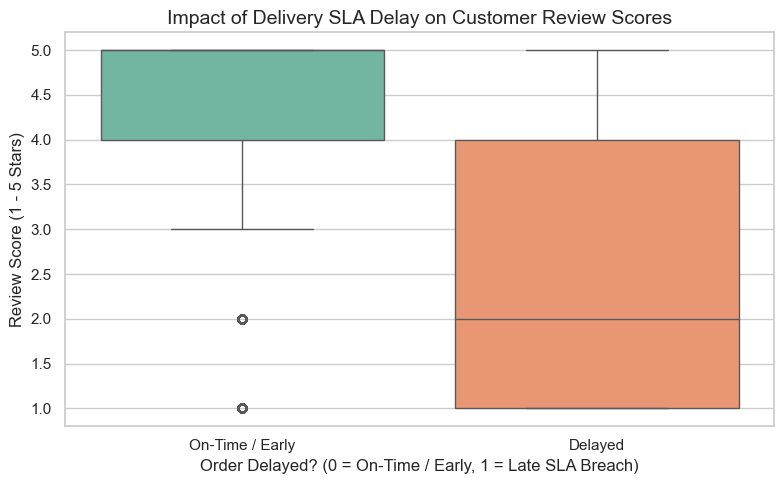


Phase 4 Exploratory Analysis Executed Successfully!


In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("Starting Exploratory Data Analysis (Phase 4)...\n")

# 1. Load Clean Processed Datasets
orders = pd.read_csv('../data/processed/clean_orders.csv')
items = pd.read_csv('../data/processed/clean_order_items.csv')
products = pd.read_csv('../data/processed/clean_products.csv')
reviews = pd.read_csv('../data/processed/clean_reviews.csv')
customers = pd.read_csv('../data/processed/clean_customers.csv')
mql = pd.read_csv('../data/olist_marketing_qualified_leads_dataset.csv')
closed_deals = pd.read_csv('../data/olist_closed_deals_dataset.csv')

# --- 2. In-Memory SQL Engine Setup ---
conn = sqlite3.connect(':memory:')
orders.to_sql('orders', conn, index=False, if_exists='replace')
items.to_sql('items', conn, index=False, if_exists='replace')
products.to_sql('products', conn, index=False, if_exists='replace')
reviews.to_sql('reviews', conn, index=False, if_exists='replace')
mql.to_sql('mql', conn, index=False, if_exists='replace')
closed_deals.to_sql('closed_deals', conn, index=False, if_exists='replace')

print("SQL Engine Initialized. Running Executive Queries...\n")

# --- SQL QUERY 1: Monthly Revenue Trajectory & Order Count ---
query_monthly = """
SELECT 
    purchase_month,
    COUNT(DISTINCT order_id) AS total_orders,
    ROUND(SUM(price), 2) AS total_revenue_brl,
    ROUND(AVG(price), 2) AS avg_order_value_brl
FROM orders o
JOIN items i USING (order_id)
WHERE order_status = 'delivered'
GROUP BY purchase_month
ORDER BY purchase_month;
"""
df_monthly = pd.read_sql_query(query_monthly, conn)
print("--- 1. MONTHLY REVENUE & AOV SUMMARY (FIRST 5 MONTHS) ---")
print(df_monthly.head())

# --- SQL QUERY 2: Logistics SLA & On-Time Delivery Rate (OTDR) ---
query_otdr = """
SELECT 
    COUNT(order_id) AS total_delivered_orders,
    SUM(CASE WHEN is_delayed = 0 THEN 1 ELSE 0 END) AS on_time_orders,
    SUM(CASE WHEN is_delayed = 1 THEN 1 ELSE 0 END) AS delayed_orders,
    ROUND(AVG(CASE WHEN is_delayed = 0 THEN 1.0 ELSE 0.0 END) * 100, 2) AS otdr_percentage,
    ROUND(AVG(delivery_time_days), 2) AS avg_delivery_days
FROM orders
WHERE order_status = 'delivered';
"""
df_otdr = pd.read_sql_query(query_otdr, conn)
print("\n--- 2. LOGISTICS PERFORMANCE & OTDR ---")
print(df_otdr)

# --- SQL QUERY 3: Marketing Seller Lead Conversion Rate ---
query_funnel = """
SELECT 
    COUNT(DISTINCT m.mql_id) AS total_leads,
    COUNT(DISTINCT c.seller_id) AS converted_sellers,
    ROUND((COUNT(DISTINCT c.seller_id) * 100.0 / COUNT(DISTINCT m.mql_id)), 2) AS lead_conversion_rate_pct
FROM mql m
LEFT JOIN closed_deals c ON m.mql_id = c.mql_id;
"""
df_funnel = pd.read_sql_query(query_funnel, conn)
print("\n--- 3. SELLER ACQUISITION FUNNEL METRICS ---")
print(df_funnel)

# --- VISUALIZATION: Impact of Delivery Delay on CSAT Review Score ---
plt.figure(figsize=(8, 5))
df_merged = orders.merge(reviews, on='order_id', how='inner')
sns.boxplot(data=df_merged, x='is_delayed', y='review_score', palette='Set2')
plt.title('Impact of Delivery SLA Delay on Customer Review Scores', fontsize=14)
plt.xlabel('Order Delayed? (0 = On-Time / Early, 1 = Late SLA Breach)', fontsize=12)
plt.ylabel('Review Score (1 - 5 Stars)', fontsize=12)
plt.xticks([0, 1], ['On-Time / Early', 'Delayed'])
plt.tight_layout()
plt.show()

print("\nPhase 4 Exploratory Analysis Executed Successfully!")